In [1]:
from pathlib import Path
import sys

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Can import from:", PROJECT_ROOT / "src")

PROJECT_ROOT: /home/ducvu/workspace/violence_detection
Can import from: /home/ducvu/workspace/violence_detection/src


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.pose_module import PoseTracker

In [4]:
VIDEO_PATH = PROJECT_ROOT / "dataset" / "RWF-2000" / "train" / "Fight" / "_2RYnSFPD_U_0.avi"

MODEL_NAME = "yolo11n-pose.pt"
MODELS_DIR = PROJECT_ROOT / "models"

CONF = 0.25
IOU = 0.7

DEVICE = 0

TRACKER_CONFIG = "bytetrack.yaml"

print("VIDEO_PATH:", VIDEO_PATH)
print("MODELS_DIR:", MODELS_DIR)

VIDEO_PATH: /home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/Fight/_2RYnSFPD_U_0.avi
MODELS_DIR: /home/ducvu/workspace/violence_detection/models


In [5]:
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}\n"
        "Put your video at pose_tracker_minimal/data/sample.mp4 "
        "or change VIDEO_PATH in the previous cell."
    )

cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps if fps > 0 else None

cap.release()

print("FPS:", fps)
print("Frame count:", frame_count)
print("Resolution:", width, "x", height)
print("Duration seconds:", duration)

FPS: 30.0
Frame count: 150
Resolution: 1280 x 720
Duration seconds: 5.0


In [6]:
pose_tracker = PoseTracker(
    model_name=MODEL_NAME,
    models_dir=MODELS_DIR,
    conf=CONF,
    iou=IOU,
    device=DEVICE,
    tracker=TRACKER_CONFIG,
    persist=True,
)

print("PoseTracker ready")
print("Model path:", pose_tracker.model_path)

[PoseTracker] Found local model: /home/ducvu/workspace/violence_detection/models/yolo11n-pose.pt
PoseTracker ready
Model path: /home/ducvu/workspace/violence_detection/models/yolo11n-pose.pt


In [7]:
SAMPLE_EVERY = 15   
MAX_SAMPLES = 30

data = []

cap = cv2.VideoCapture(str(VIDEO_PATH))

frame_idx = 0
sample_count = 0

while cap.isOpened():
    ok, frame_bgr = cap.read()

    if not ok:
        break

    should_sample = frame_idx % SAMPLE_EVERY == 0

    if should_sample:
        timestamp_sec = frame_idx / fps if fps > 0 else None

        detections = pose_tracker.process_frame(frame_bgr)

        record = {
            "frame_idx": frame_idx,
            "timestamp_sec": timestamp_sec,
            "frame_bgr": frame_bgr.copy(),
            "detections": detections,
        }

        data.append(record)

        print(
            f"frame={frame_idx:06d} | "
            f"time={timestamp_sec:.2f}s | "
            f"people={len(detections)}"
        )

        sample_count += 1

        if sample_count >= MAX_SAMPLES:
            break

    frame_idx += 1

cap.release()

print("Total records in data:", len(data))

frame=000000 | time=0.00s | people=9
frame=000015 | time=0.50s | people=3
frame=000030 | time=1.00s | people=5
frame=000045 | time=1.50s | people=5
frame=000060 | time=2.00s | people=3
frame=000075 | time=2.50s | people=4
frame=000090 | time=3.00s | people=5
frame=000105 | time=3.50s | people=5
frame=000120 | time=4.00s | people=5
frame=000135 | time=4.50s | people=7
Total records in data: 10


In [8]:
if len(data) == 0:
    raise RuntimeError("data is empty. Check video path or sampling config.")

sample_record = data[0]

print("Record keys:", sample_record.keys())
print("Frame index:", sample_record["frame_idx"])
print("Timestamp:", sample_record["timestamp_sec"])
print("Frame shape:", sample_record["frame_bgr"].shape)
print("Number of detections:", len(sample_record["detections"]))

sample_record["detections"][:2]

Record keys: dict_keys(['frame_idx', 'timestamp_sec', 'frame_bgr', 'detections'])
Frame index: 0
Timestamp: 0.0
Frame shape: (720, 1280, 3)
Number of detections: 9


[{'track_id': 1,
  'bbox': [389.23, 20.66, 499.63, 222.08],
  'keypoints': [[447.6, 62.95, 0.96],
   [452.43, 56.73, 0.92],
   [441.25, 56.73, 0.95],
   [458.99, 57.86, 0.64],
   [429.34, 57.59, 0.81],
   [474.29, 90.77, 0.99],
   [410.12, 90.17, 0.99],
   [486.88, 136.49, 0.87],
   [398.78, 135.48, 0.9],
   [466.12, 152.34, 0.76],
   [425.38, 146.45, 0.79],
   [464.15, 178.46, 0.93],
   [423.29, 178.76, 0.93],
   [465.74, 233.85, 0.45],
   [424.84, 233.87, 0.47],
   [458.53, 274.41, 0.13],
   [431.43, 274.03, 0.14]]},
 {'track_id': 2,
  'bbox': [64.75, 7.8, 172.71, 304.96],
  'keypoints': [[126.83, 20.52, 0.17],
   [127.33, 14.2, 0.03],
   [123.33, 14.0, 0.26],
   [126.25, 14.41, 0.01],
   [110.01, 12.44, 0.48],
   [130.14, 40.96, 0.54],
   [85.44, 39.08, 0.9],
   [138.6, 77.88, 0.41],
   [87.0, 79.58, 0.96],
   [152.67, 73.23, 0.46],
   [149.28, 72.5, 0.91],
   [124.54, 147.99, 0.93],
   [94.58, 149.17, 0.97],
   [121.26, 233.71, 0.72],
   [98.14, 234.45, 0.89],
   [106.75, 294.24, 0

In [9]:
COCO_SKELETON = [
    (5, 6),    # shoulders
    (5, 7),    # left upper arm
    (7, 9),    # left lower arm
    (6, 8),    # right upper arm
    (8, 10),   # right lower arm
    (5, 11),   # left body
    (6, 12),   # right body
    (11, 12),  # hips
    (11, 13),  # left upper leg
    (13, 15),  # left lower leg
    (12, 14),  # right upper leg
    (14, 16),  # right lower leg
    (0, 1),    # nose-left eye
    (0, 2),    # nose-right eye
    (1, 3),    # left eye-left ear
    (2, 4),    # right eye-right ear
]


def draw_pose_record(
    record: dict,
    keypoint_conf_thres: float = 0.3,
    draw_track_id: bool = True,
) -> np.ndarray:
    """
    Draw bounding boxes, track IDs, and COCO keypoints on one stored frame record.

    Args:
        record:
            One item from data.
        keypoint_conf_thres:
            Minimum keypoint confidence to draw.
        draw_track_id:
            Whether to draw track_id text above each bounding box.

    Returns:
        Annotated RGB image for matplotlib display.
    """
    frame_bgr = record["frame_bgr"].copy()
    detections = record["detections"]

    for person in detections:
        bbox = person["bbox"]
        track_id = person["track_id"]
        keypoints = person["keypoints"]

        x1, y1, x2, y2 = [int(v) for v in bbox]

        cv2.rectangle(
            frame_bgr,
            (x1, y1),
            (x2, y2),
            color=(0, 255, 0),
            thickness=2,
        )

        if draw_track_id:
            label = f"id={track_id}" if track_id is not None else "id=None"
            cv2.putText(
                frame_bgr,
                label,
                (x1, max(0, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )

        keypoints_np = np.array(keypoints, dtype=np.float32)

        # Draw skeleton lines.
        for joint_a, joint_b in COCO_SKELETON:
            xa, ya, ca = keypoints_np[joint_a]
            xb, yb, cb = keypoints_np[joint_b]

            if ca >= keypoint_conf_thres and cb >= keypoint_conf_thres:
                cv2.line(
                    frame_bgr,
                    (int(xa), int(ya)),
                    (int(xb), int(yb)),
                    color=(255, 0, 0),
                    thickness=2,
                )

        # Draw keypoint dots.
        for x, y, conf in keypoints_np:
            if conf >= keypoint_conf_thres:
                cv2.circle(
                    frame_bgr,
                    (int(x), int(y)),
                    radius=4,
                    color=(0, 0, 255),
                    thickness=-1,
                )

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frame_rgb

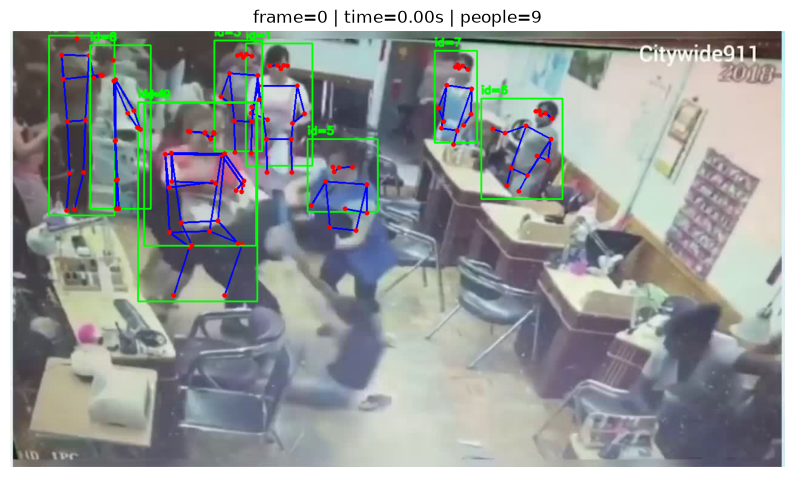

In [10]:
record_idx = 0

annotated_rgb = draw_pose_record(data[record_idx])

plt.figure(figsize=(10, 6))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title(
    f"frame={data[record_idx]['frame_idx']} | "
    f"time={data[record_idx]['timestamp_sec']:.2f}s | "
    f"people={len(data[record_idx]['detections'])}"
)
plt.show()

Records with people: 10


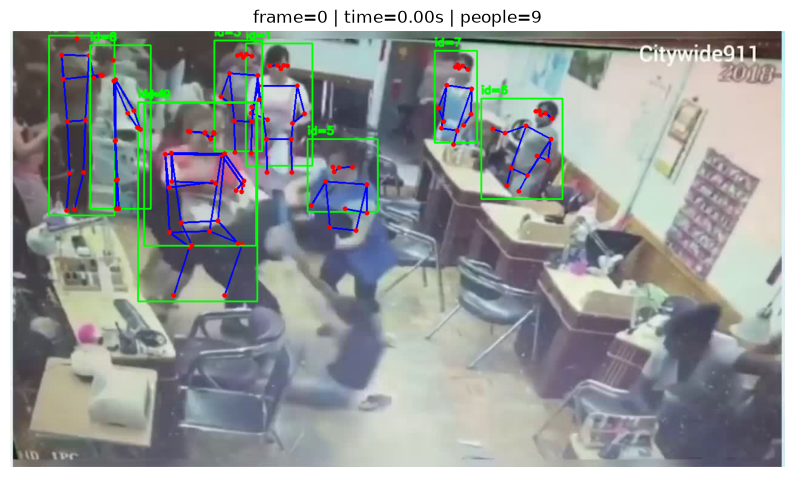

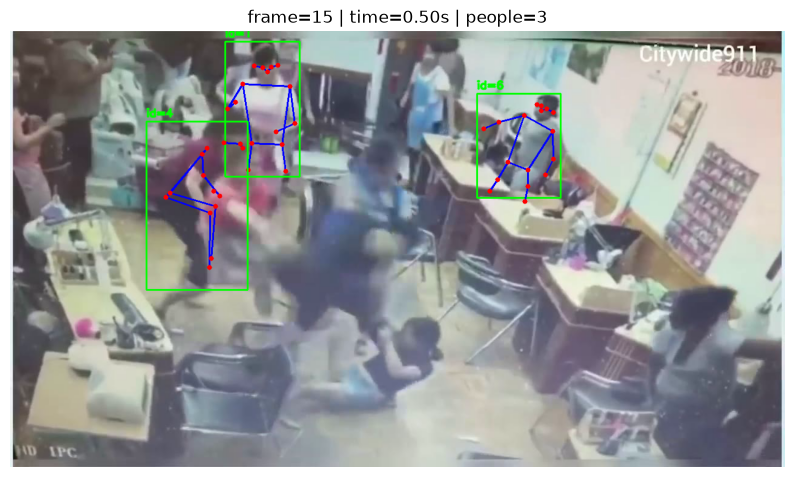

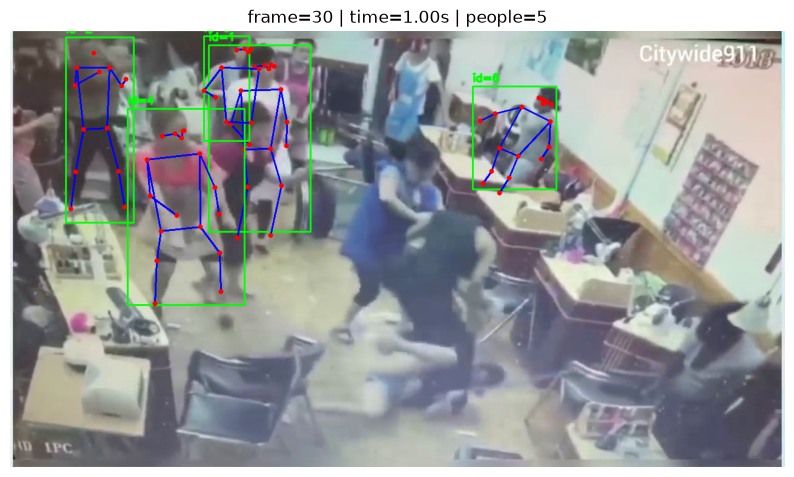

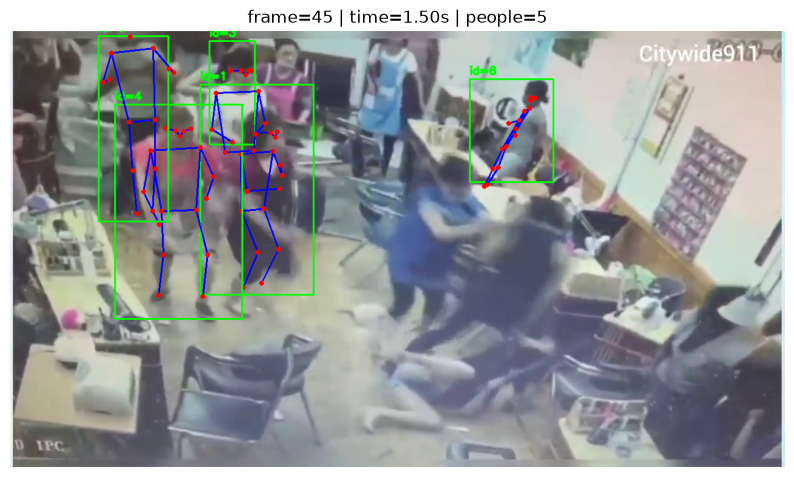

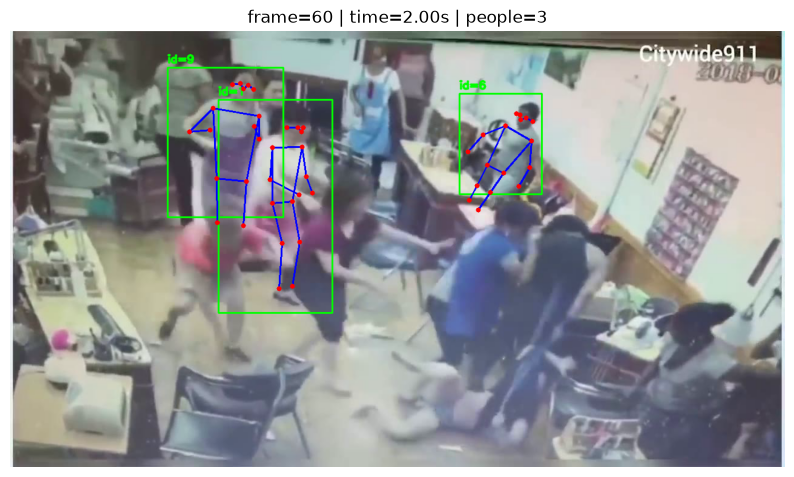

In [11]:
records_with_people = [
    record for record in data
    if len(record["detections"]) > 0
]

print("Records with people:", len(records_with_people))

if len(records_with_people) == 0:
    print("No people detected in sampled frames.")
else:
    max_show = min(5, len(records_with_people))

    for i in range(max_show):
        record = records_with_people[i]
        annotated_rgb = draw_pose_record(record)

        plt.figure(figsize=(10, 6))
        plt.imshow(annotated_rgb)
        plt.axis("off")
        plt.title(
            f"frame={record['frame_idx']} | "
            f"time={record['timestamp_sec']:.2f}s | "
            f"people={len(record['detections'])}"
        )
        plt.show()

In [12]:
preview_data = []

for record in data[:3]:
    preview_data.append(
        {
            "frame_idx": record["frame_idx"],
            "timestamp_sec": record["timestamp_sec"],
            "num_people": len(record["detections"]),
            "detections": record["detections"],
        }
    )

preview_data

[{'frame_idx': 0,
  'timestamp_sec': 0.0,
  'num_people': 9,
  'detections': [{'track_id': 1,
    'bbox': [389.23, 20.66, 499.63, 222.08],
    'keypoints': [[447.6, 62.95, 0.96],
     [452.43, 56.73, 0.92],
     [441.25, 56.73, 0.95],
     [458.99, 57.86, 0.64],
     [429.34, 57.59, 0.81],
     [474.29, 90.77, 0.99],
     [410.12, 90.17, 0.99],
     [486.88, 136.49, 0.87],
     [398.78, 135.48, 0.9],
     [466.12, 152.34, 0.76],
     [425.38, 146.45, 0.79],
     [464.15, 178.46, 0.93],
     [423.29, 178.76, 0.93],
     [465.74, 233.85, 0.45],
     [424.84, 233.87, 0.47],
     [458.53, 274.41, 0.13],
     [431.43, 274.03, 0.14]]},
   {'track_id': 2,
    'bbox': [64.75, 7.8, 172.71, 304.96],
    'keypoints': [[126.83, 20.52, 0.17],
     [127.33, 14.2, 0.03],
     [123.33, 14.0, 0.26],
     [126.25, 14.41, 0.01],
     [110.01, 12.44, 0.48],
     [130.14, 40.96, 0.54],
     [85.44, 39.08, 0.9],
     [138.6, 77.88, 0.41],
     [87.0, 79.58, 0.96],
     [152.67, 73.23, 0.46],
     [149.28, 7